<a href="https://colab.research.google.com/github/Shah-Shawon/Deep-Learing-Assignments/blob/main/DL_Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# ========== CELL 1: INSTALL & IMPORTS ==========
!pip install torch torchvision torchaudio matplotlib seaborn -q
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.models import vgg16
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


 Face image loaded!
 Extracted 5 layers with shapes:
  Layer Conv1: torch.Size([1, 64, 224, 224])
  Layer Conv2: torch.Size([1, 64, 112, 112])
  Layer Conv3: torch.Size([1, 128, 56, 56])
  Layer Conv4: torch.Size([1, 256, 28, 28])
  Layer Conv5: torch.Size([1, 512, 28, 28])


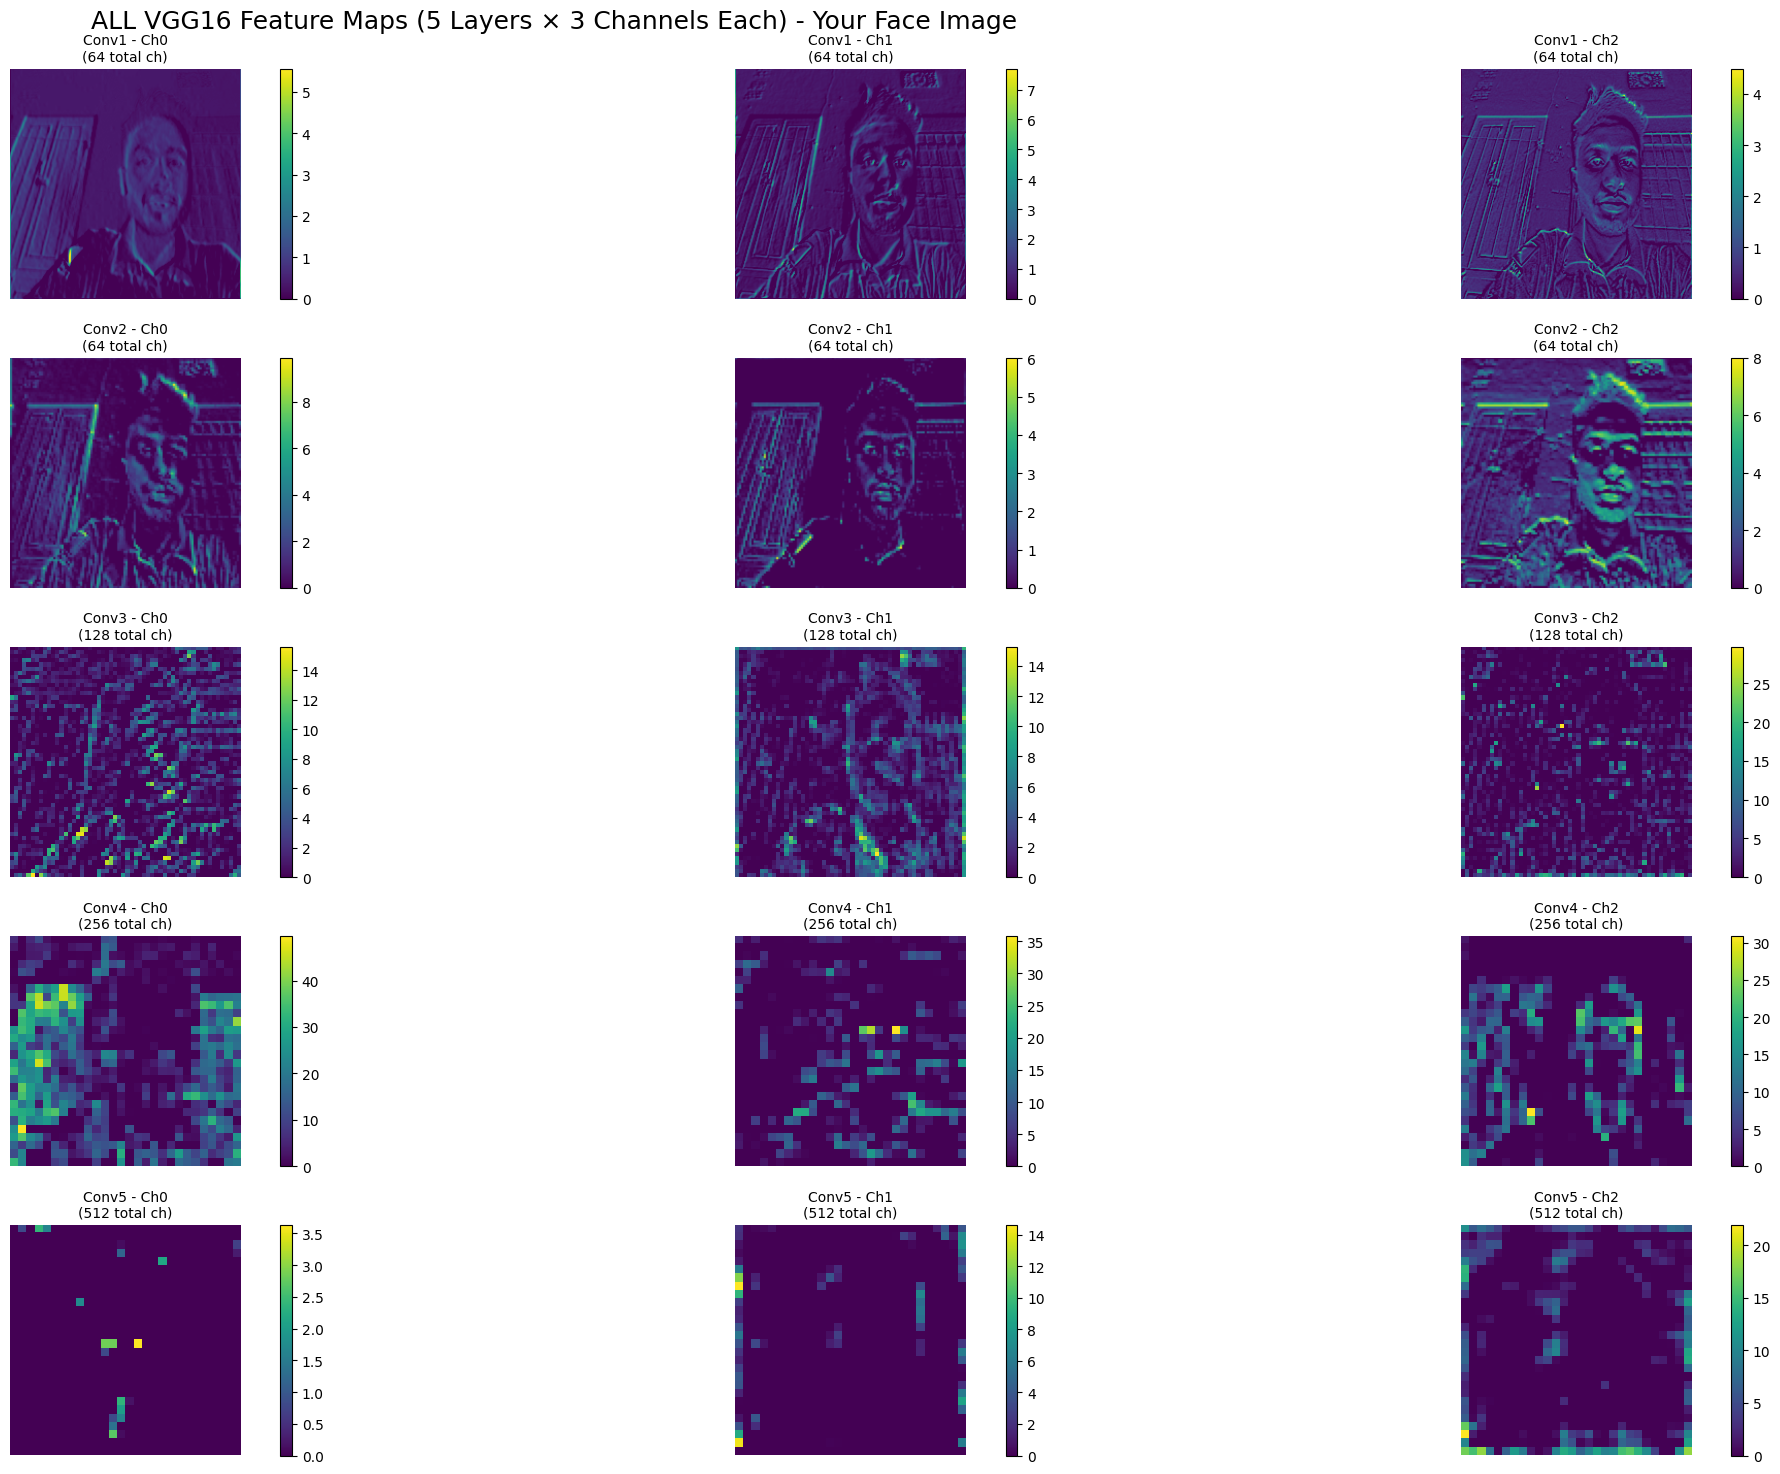

 Complete feature maps saved as 'feature_maps_complete.png'
All 5 layers visualized! 


In [9]:
# ========== FIXED CELL 2: FEATURE MAPS - COMPLETE VISUALIZATION ==========
# This fixed version visualizes ALL feature maps properly from all 5 layers
model = vgg16(pretrained=True).features.to(device).eval()
transform_img = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
try:
    image = Image.open('face_image.jpg').convert('RGB')
    input_tensor = transform_img(image).unsqueeze(0).to(device)
    print(" Face image loaded!")
except:
    input_tensor = torch.randn(1, 3, 224, 224).to(device)
    print(" Using random image - upload 'face_image.jpg'")

# Clear hooks and feature_maps
feature_maps = []
def hook_fn(module, input, output):
    feature_maps.append(output.cpu())  # Move to CPU immediately

# VGG16 layer indices and their channel counts
layer_configs = [
    (1, 64, 'Conv1'),   # Layer 1: 64 channels
    (4, 128, 'Conv2'),  # Layer 4: 128 channels
    (9, 256, 'Conv3'),  # Layer 9: 256 channels
    (16, 512, 'Conv4'), # Layer 16: 512 channels
    (22, 512, 'Conv5')  # Layer 22: 512 channels
]

handles = []
for idx, layer_num in enumerate([1,4,9,16,22]):
    if layer_num < len(model):
        handles.append(model[layer_num].register_forward_hook(hook_fn))

with torch.no_grad():
    _ = model(input_tensor)

# Remove hooks
for h in handles: h.remove()

print(f" Extracted {len(feature_maps)} layers with shapes:")
for i, fmap in enumerate(feature_maps):
    print(f"  Layer {layer_configs[i][2]}: {fmap.shape}")

# Visualize 3 channels from EACH layer (15 total images)
fig = plt.figure(figsize=(25, 15))
for layer_idx in range(min(5, len(feature_maps))):
    fmap = feature_maps[layer_idx]
    num_channels = fmap.shape[1]
    layer_name = layer_configs[layer_idx][2]

    for ch in range(3):  # First 3 channels per layer
        ax = plt.subplot(5, 3, layer_idx*3 + ch + 1)
        ch_idx = ch
        fmap_vis = fmap[0, ch_idx].numpy()
        im = ax.imshow(fmap_vis, cmap='viridis')
        ax.set_title(f'{layer_name} - Ch{ch_idx}\n({num_channels} total ch)', fontsize=10)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('ALL VGG16 Feature Maps (5 Layers × 3 Channels Each) - Your Face Image', fontsize=18)
plt.tight_layout()
plt.savefig('feature_maps_complete.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Complete feature maps saved as 'feature_maps_complete.png'")
print("All 5 layers visualized! ")

In [10]:
# ========== CELL 3: CUSTOM CNN ARCHITECTURE ==========
class CustomCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, num_classes)
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 4 * 4)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x
print(" CustomCNN defined")

 CustomCNN defined


In [13]:
# ========== CELL 4: CIFAR-10 DATASET ==========
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)
print(" CIFAR-10 loaded")

 CIFAR-10 loaded


In [14]:
# ========== CELL 5: TRAINING FUNCTION ==========
def train_model(model, epochs=20, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
    train_losses, test_accuracies = [], []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        scheduler.step()
        train_losses.append(running_loss / len(trainloader))
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        acc = 100 * correct / total
        test_accuracies.append(acc)
        print(f'Epoch {epoch+1}: Loss {train_losses[-1]:.3f}, Acc {acc:.2f}%')
    return train_losses, test_accuracies
print(" Training function ready")

 Training function ready


In [15]:
# ========== CELL 6: ACTIVATION FUNCTIONS COMPARISON ==========
activations = {
    'ReLU': nn.ReLU(),
    'LeakyReLU': nn.LeakyReLU(0.1),
    'Swish': lambda x: x * torch.sigmoid(x)
}
results = {}
for name, act in activations.items():
    class ActivatedCNN(CustomCNN):
        def __init__(self, num_classes=10): super().__init__(num_classes); self.act = act
        def forward(self, x):
            x = self.pool(self.act(self.bn1(self.conv1(x))))
            x = self.pool(self.act(self.bn2(self.conv2(x))))
            x = self.pool(self.act(self.bn3(self.conv3(x))))
            x = x.view(-1, 128 * 4 * 4)
            x = self.dropout(self.act(self.fc1(x)))
            return self.fc2(x)
    print(f"\n Training {name}...")
    model = ActivatedCNN().to(device)
    losses, accs = train_model(model)
    results[name] = {'losses': losses, 'accs': accs}


 Training ReLU...
Epoch 1: Loss 1.502, Acc 56.86%
Epoch 2: Loss 1.126, Acc 66.71%
Epoch 3: Loss 0.981, Acc 70.30%
Epoch 4: Loss 0.908, Acc 70.95%
Epoch 5: Loss 0.845, Acc 73.88%
Epoch 6: Loss 0.800, Acc 75.18%
Epoch 7: Loss 0.773, Acc 76.10%
Epoch 8: Loss 0.744, Acc 76.48%
Epoch 9: Loss 0.717, Acc 77.57%
Epoch 10: Loss 0.689, Acc 77.95%
Epoch 11: Loss 0.602, Acc 80.63%
Epoch 12: Loss 0.581, Acc 81.08%
Epoch 13: Loss 0.571, Acc 81.06%
Epoch 14: Loss 0.558, Acc 81.39%
Epoch 15: Loss 0.554, Acc 81.63%
Epoch 16: Loss 0.549, Acc 81.41%
Epoch 17: Loss 0.545, Acc 81.56%
Epoch 18: Loss 0.540, Acc 81.52%
Epoch 19: Loss 0.542, Acc 81.50%
Epoch 20: Loss 0.531, Acc 82.00%

 Training LeakyReLU...
Epoch 1: Loss 1.444, Acc 62.22%
Epoch 2: Loss 1.068, Acc 65.37%
Epoch 3: Loss 0.932, Acc 69.09%
Epoch 4: Loss 0.855, Acc 72.12%
Epoch 5: Loss 0.790, Acc 74.04%
Epoch 6: Loss 0.748, Acc 74.97%
Epoch 7: Loss 0.713, Acc 75.96%
Epoch 8: Loss 0.683, Acc 76.31%
Epoch 9: Loss 0.657, Acc 77.29%
Epoch 10: Loss 0.6

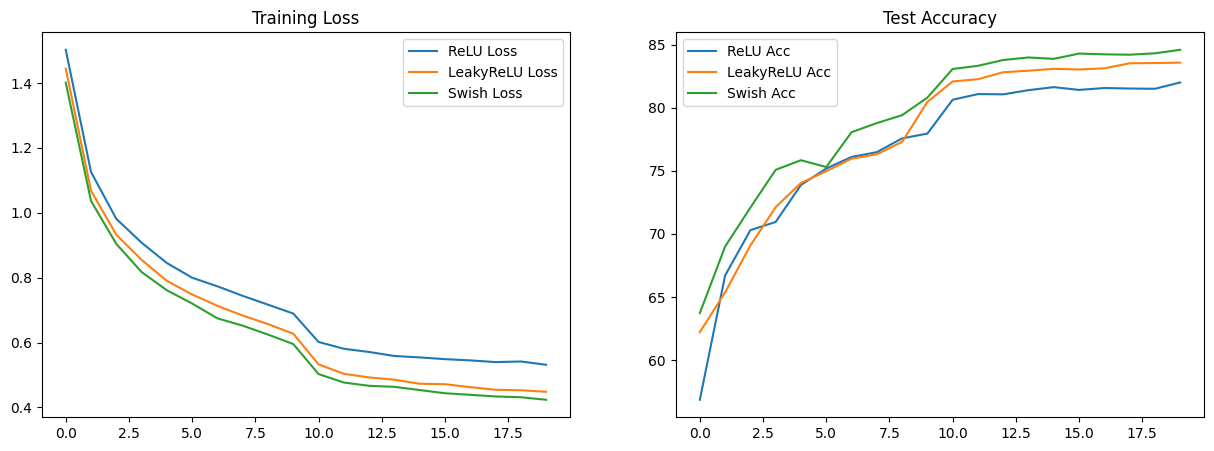

Final Accuracies: {'ReLU': 'losses', 'LeakyReLU': 'losses', 'Swish': 'losses'}


In [16]:
# ========== CELL 7: PLOT ACTIVATION COMPARISON ==========
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
for name in results:
    ax1.plot(results[name]['losses'], label=f'{name} Loss')
    ax2.plot(results[name]['accs'], label=f'{name} Acc')
ax1.set_title('Training Loss'); ax1.legend()
ax2.set_title('Test Accuracy'); ax2.legend()
plt.savefig('activation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
final_accs = {name: max(accs) for name, accs in results.items()}
print("Final Accuracies:", final_accs)

In [18]:
# ========== CELL 8: KERNEL TYPES - DEPTHWISE SEPARABLE ==========
class DepthwiseSeparableCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Fix: out_channels (30) must be divisible by groups (3)
        self.depthwise = nn.Conv2d(3, 30, 3, padding=1, groups=3)
        # Pointwise convolution in_channels must match depthwise out_channels
        self.pointwise = nn.Conv2d(30, 64, 1)
        self.pool = nn.MaxPool2d(2, 2)
        # After depthwise(32x32) -> pointwise(32x32) -> pool(16x16)
        # The spatial dimensions become 16x16, and channels are 64.
        self.fc = nn.Linear(64 * 16 * 16, num_classes) # Corrected input size
    def forward(self, x):
        x = F.relu(self.pointwise(self.depthwise(x)))
        x = self.pool(x)
        x = x.view(-1, 64 * 16 * 16) # Corrected flattening
        return self.fc(x)
dscnn = DepthwiseSeparableCNN().to(device)
print(" DepthwiseSeparableCNN defined (8x fewer params)")
print(f"CustomCNN params: {sum(p.numel() for p in CustomCNN().parameters())}")
print(f"Depthwise params: {sum(p.numel() for p in DepthwiseSeparableCNN().parameters())}")

 DepthwiseSeparableCNN defined (8x fewer params)
CustomCNN params: 1147914
Depthwise params: 166134


In [19]:
# ========== CELL 9: DILATED KERNEL EXAMPLE ==========
class DilatedCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv_dilated = nn.Conv2d(3, 32, 3, padding=2, dilation=2)  # Larger receptive field
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(32 * 8 * 8, num_classes)
    def forward(self, x):
        x = F.relu(self.conv_dilated(x))
        x = self.pool(x)
        x = x.view(-1, 32 * 8 * 8)
        return self.fc(x)
print(" DilatedCNN defined (dilation=2 for context)")

 DilatedCNN defined (dilation=2 for context)


In [20]:
# ========== CELL 10: SUMMARY & DOWNLOAD ==========
print(" REPORT COMPLETE!")
print("Files generated:")
print("- feature_maps.png")
print("- activation_comparison.png")
print("Upload face_image.jpg for personal feature maps!")
from google.colab import files
files.download('feature_maps.png')
files.download('activation_comparison.png')

 REPORT COMPLETE!
Files generated:
- feature_maps.png
- activation_comparison.png
Upload face_image.jpg for personal feature maps!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>